In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../dataset_raw/train_pca.csv")

print(df.shape)

df.head()

(50808, 12)


,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2,Credit_Score
0,0.690476,2,2,0,0.216025,0.335070,0.056151,0.047829,0.146897,-0.041306,0.042562,2
1,0.190476,1,1,0,-0.319038,0.112770,0.227198,0.055694,0.117256,0.278801,0.108811,0
2,0.428571,1,1,3,-0.419239,0.069822,0.232682,-0.110793,0.251450,-0.200276,0.056651,0
3,0.476190,1,0,0,-0.257237,-0.237483,0.376886,-0.068433,0.012728,-0.168980,0.037451,0
4,0.452381,1,1,5,-0.502552,0.073821,0.226193,-0.284319,-0.015748,-0.198335,-0.034793,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50808 entries, 0 to 50807
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50808 non-null  float64
 1   Credit_Mix             50808 non-null  int64  
 2   Payment_of_Min_Amount  50808 non-null  int64  
 3   Payment_Behaviour      50808 non-null  int64  
 4   pc1_1                  50808 non-null  float64
 5   pc1_2                  50808 non-null  float64
 6   pc1_3                  50808 non-null  float64
 7   pc1_4                  50808 non-null  float64
 8   pc1_5                  50808 non-null  float64
 9   pc2_1                  50808 non-null  float64
 10  pc2_2                  50808 non-null  float64
 11  Credit_Score           50808 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 4.7 MB


In [5]:
df.describe()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2,Credit_Score
count,50808.000000,50808.000000,50808.000000,50808.000000,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,5.080800e+04,50808.000000
mean,0.468683,1.515608,1.332389,2.958668,8.181143e-17,2.258555e-17,-4.090571e-17,-1.846001e-17,1.061101e-17,4.915678e-17,-1.185217e-17,1.000000
std,0.258129,1.009663,0.685671,1.976027,5.687249e-01,2.046556e-01,1.705790e-01,1.646248e-01,1.531693e-01,2.553639e-01,1.215272e-01,0.816505
min,0.000000,0.000000,0.000000,0.000000,-9.360719e-01,-6.738205e-01,-6.204886e-01,-6.176263e-01,-5.724390e-01,-3.136296e-01,-7.238451e-01,0.000000
25%,0.261905,1.000000,1.000000,1.000000,-4.817875e-01,-1.436896e-01,-1.179284e-01,-1.120678e-01,-1.029299e-01,-2.043387e-01,-4.335699e-02,0.000000
50%,0.452381,1.000000,1.000000,3.000000,-1.769058e-01,1.213647e-02,7.199985e-04,-2.277561e-04,-2.779831e-04,-8.949644e-02,1.908437e-02,1.000000
75%,0.666667,2.000000,2.000000,5.000000,5.157793e-01,1.492467e-01,1.188504e-01,1.115222e-01,1.025901e-01,1.367666e-01,5.955841e-02,2.000000
max,1.000000,3.000000,2.000000,6.000000,1.416377e+00,6.245706e-01,6.312982e-01,6.033564e-01,6.464555e-01,1.104966e+00,4.862872e-01,2.000000


In [6]:
df.isnull().sum()

Age                      0
Credit_Mix               0
Payment_of_Min_Amount    0
Payment_Behaviour        0
pc1_1                    0
pc1_2                    0
pc1_3                    0
pc1_4                    0
pc1_5                    0
pc2_1                    0
pc2_2                    0
Credit_Score             0
dtype: int64

In [7]:
df.isnull().mean()*100

Age                      0.0
Credit_Mix               0.0
Payment_of_Min_Amount    0.0
Payment_Behaviour        0.0
pc1_1                    0.0
pc1_2                    0.0
pc1_3                    0.0
pc1_4                    0.0
pc1_5                    0.0
pc2_1                    0.0
pc2_2                    0.0
Credit_Score             0.0
dtype: float64

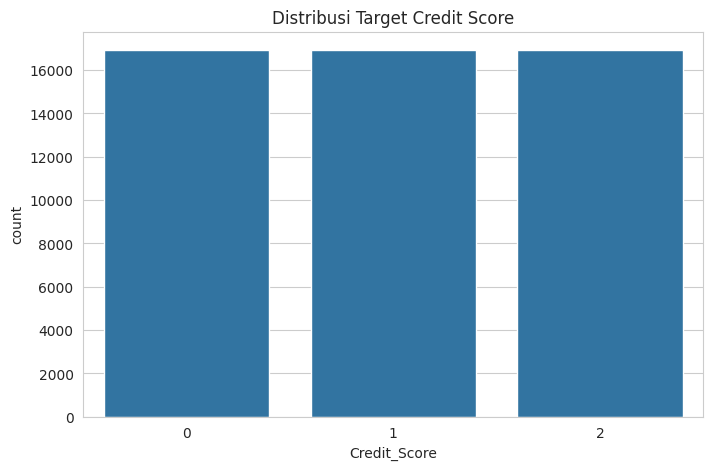

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Credit_Score',
    data=df
)

plt.title('Distribusi Target Credit Score')
plt.show()

In [9]:
print(df.columns)

Index(['Age', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour',
       'pc1_1', 'pc1_2', 'pc1_3', 'pc1_4', 'pc1_5', 'pc2_1', 'pc2_2',
       'Credit_Score'],
      dtype='object')


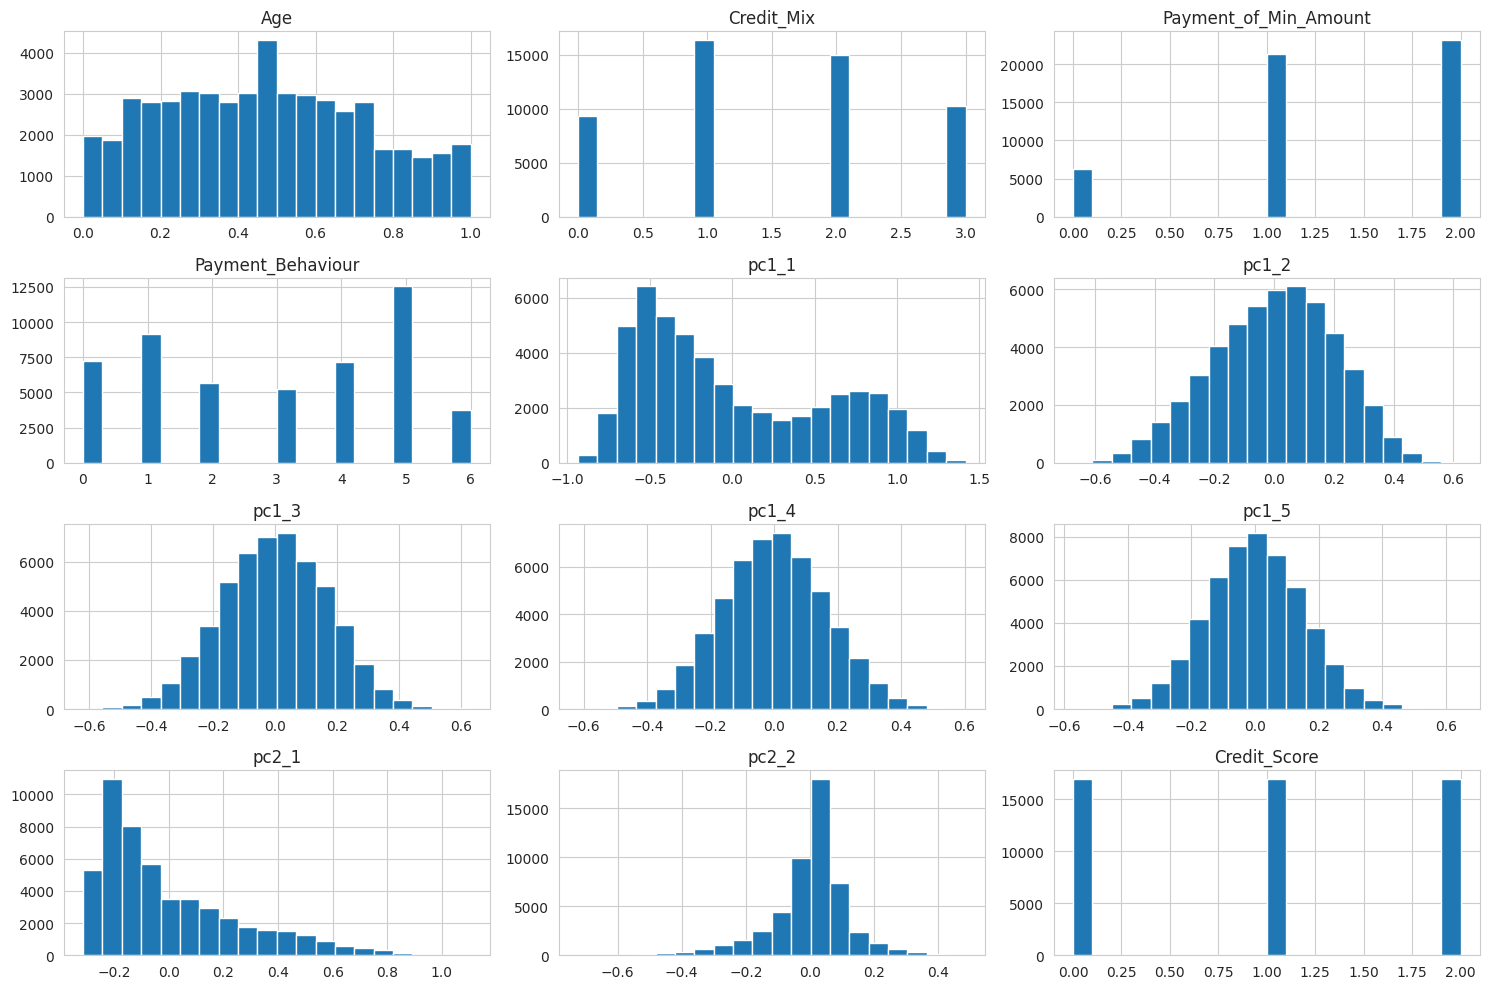

In [10]:
numeric_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

df[numeric_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

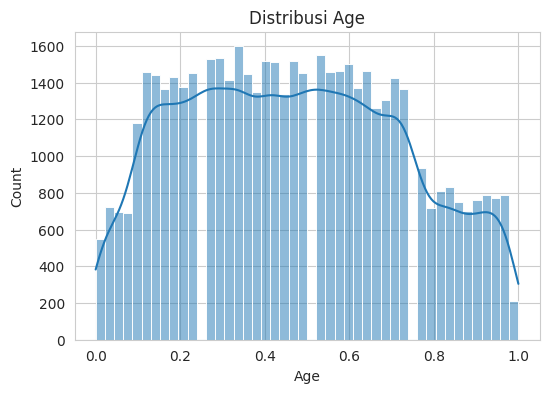

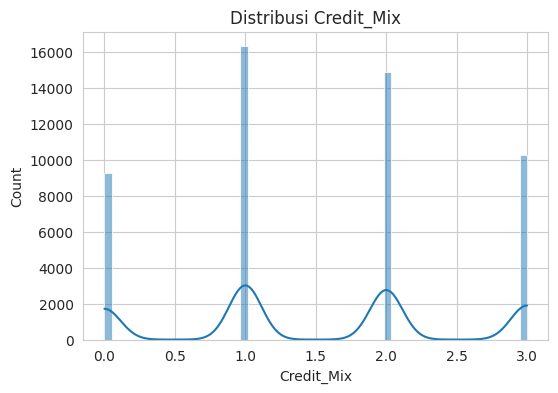

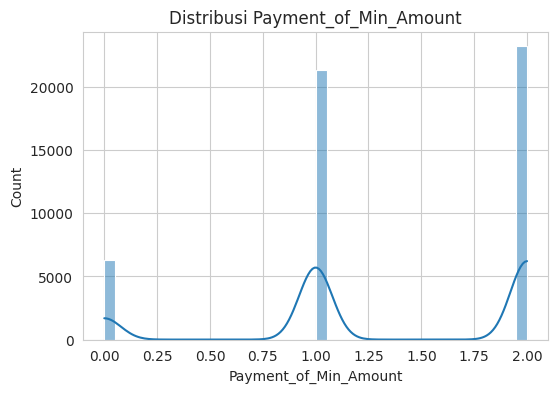

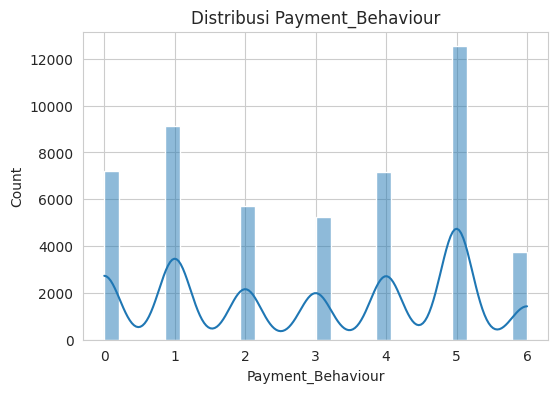

In [11]:
features = numeric_columns[:4]

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribusi {col}')

    plt.show()

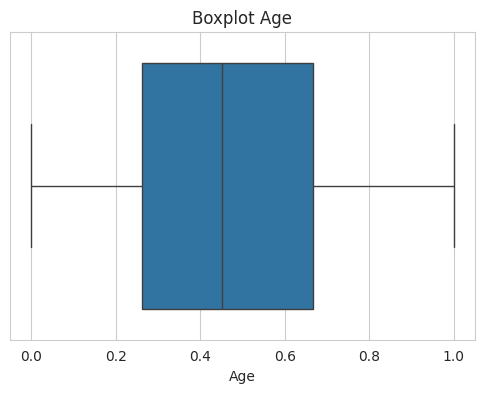

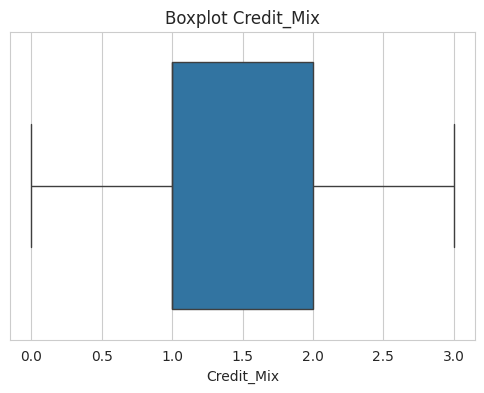

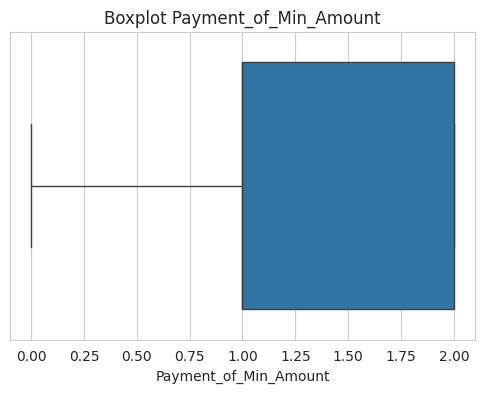

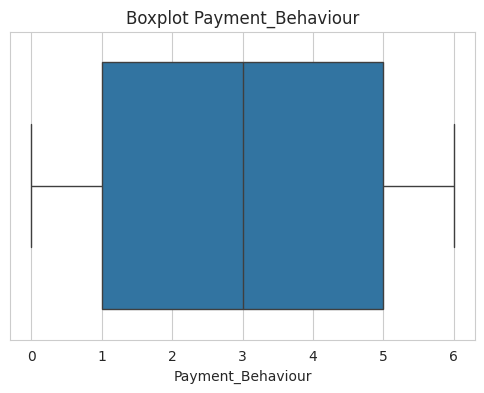

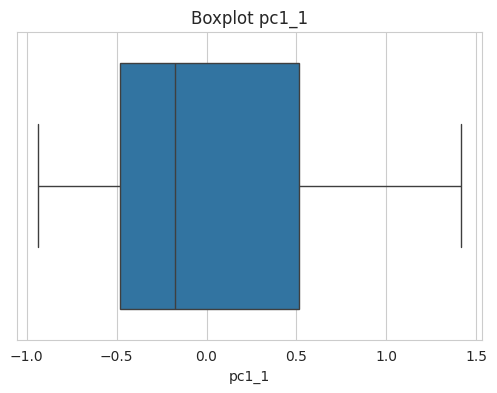

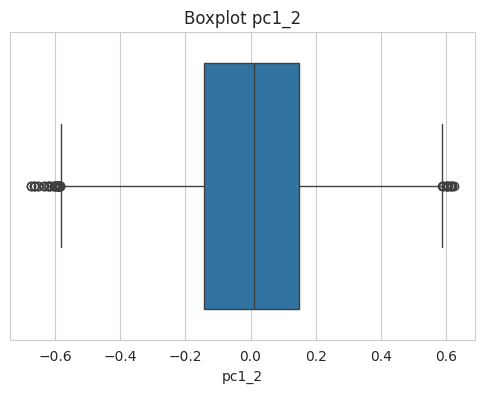

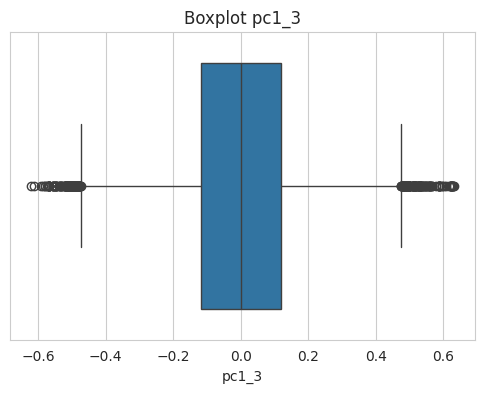

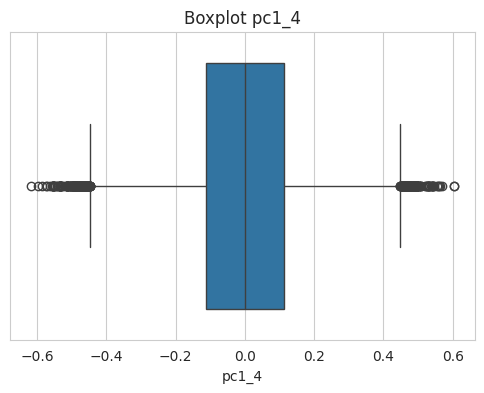

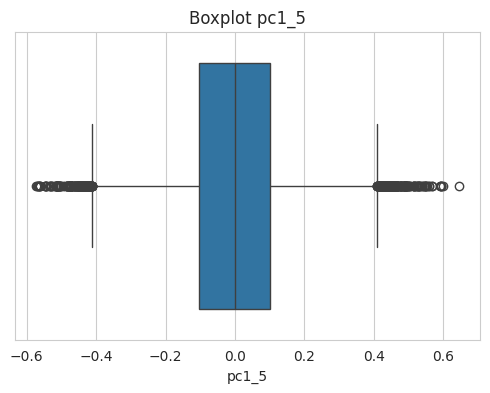

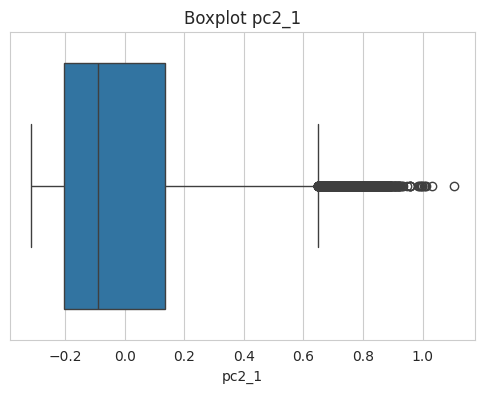

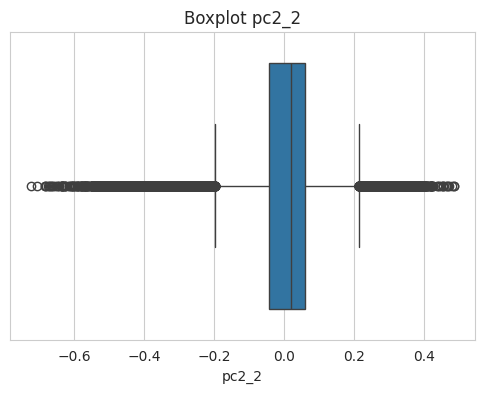

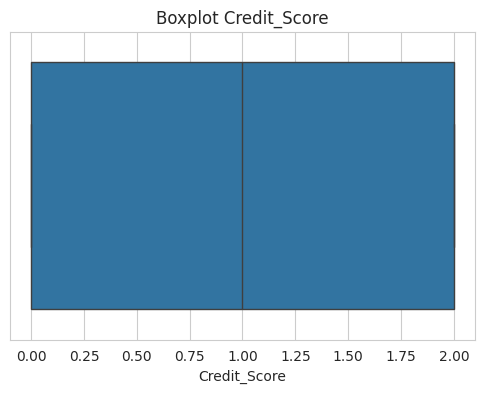

In [15]:
for col in numeric_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot {col}')

    plt.show()

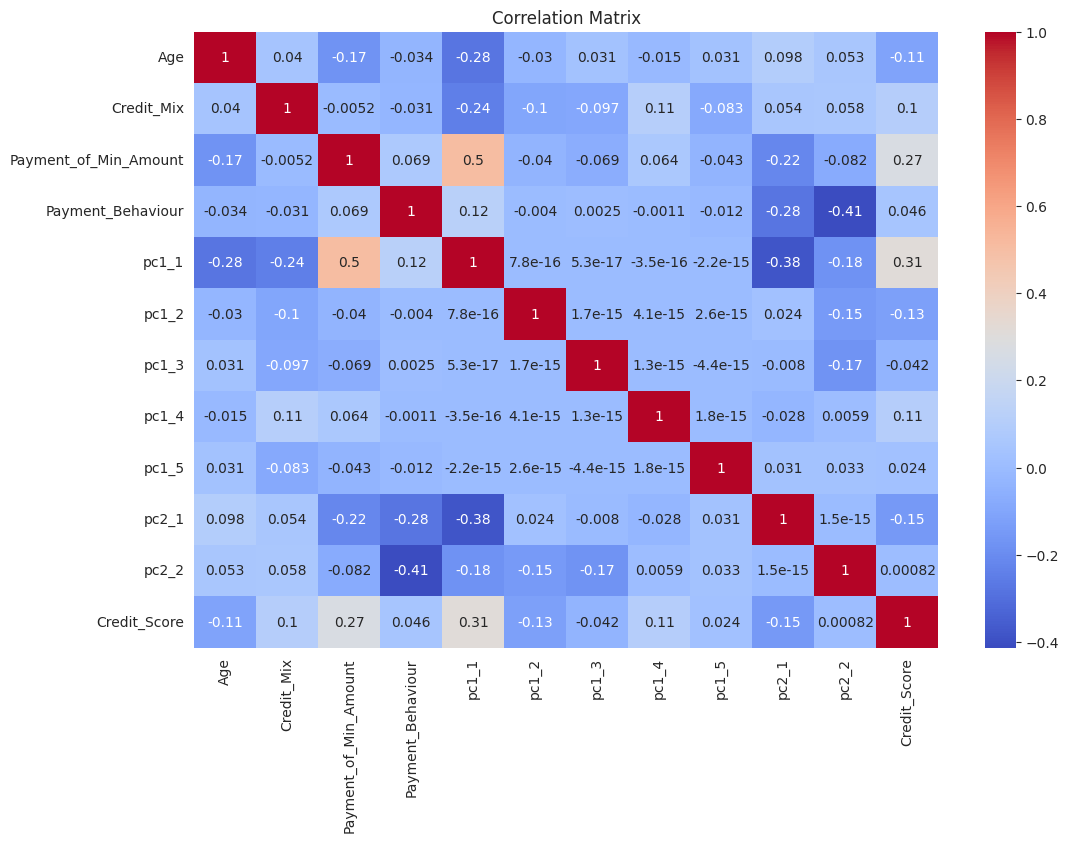

In [16]:
plt.figure(figsize=(12,8))

corr = df[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [17]:
target_dist = (
    df['Credit_Score']
    .value_counts(normalize=True)
    * 100
)

print(target_dist)

Credit_Score
2    33.333333
0    33.333333
1    33.333333
Name: proportion, dtype: float64
